<img src="https://raw.githubusercontent.com/carubbi/MQ/main/notebooks/assets/imgs/unifor-logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos em Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

# **Aula 8 — Forma e interpretação das distribuições**

## 1. Objetivos de aprendizagem

Ao final da aula, o aluno será capaz de:

- interpretar a assimetria e a forma das distribuições com apoio de gráficos e medidas;
- usar quartis e IQR para identificar valores discrepantes pelo critério de Tukey;
- distinguir valores discrepantes de erros comprovados.


## 2. Agenda

1. Conceitos para interpretar os gráficos — 10 min
2. Medidas de forma da distribuição — 40 min
3. Identificação de valores discrepantes — 20 min
4. Acompanhamento da AP1 — 30 min

As visualizações serão apresentadas prontas. A atividade prática concentra-se na interpretação dos gráficos e na identificação de valores discrepantes.

Dos 40 minutos da seção 4, cerca de 5 serão dedicados à curtose como complemento, com figura e cálculo apresentados prontos.


## 3. Conceitos para interpretar os gráficos

O histograma apresenta frequências em intervalos. A **cauda** é a região que se estende em direção aos valores mais afastados do centro. Examine concentrações, caudas e possíveis múltiplos picos antes de interpretar um coeficiente.

No boxplot, a caixa vai do primeiro ao terceiro quartil, e a linha interna indica a mediana. O intervalo interquartil é $\operatorname{IQR}=Q_3-Q_1$, em que $Q_1$ e $Q_3$ são os quartis inferior e superior. Retomaremos as cercas e as hastes na seção 5 (MORETTIN; BUSSAB, 2010, pp. 64–65).

**Robustez** significa menor sensibilidade a observações extremas. Mediana e IQR são mais robustos que média e desvio-padrão. Isso não significa que permaneçam sempre iguais quando os dados mudam (PINHEIRO et al., 2009, pp. 41–42).

In [1]:
# Importar as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Carregar a base processada
url = 'https://raw.githubusercontent.com/carubbi/MQ/main/data/processed/penguins.csv'
df = pd.read_csv(url)
df.head()

,ID,SPECIES,ISLAND,SEX,DATE_EGG,YEAR,CULMEN_LENGTH,CULMEN_DEPTH,FLIPPER_LENGTH,BODY_MASS
0,PAL0708_N1A1,Adelie,Torgersen,male,2007-11-11,2007,39.1,18.7,181.0,3750.0
1,PAL0708_N1A2,Adelie,Torgersen,female,2007-11-11,2007,39.5,17.4,186.0,3800.0
2,PAL0708_N2A1,Adelie,Torgersen,female,2007-11-16,2007,40.3,18.0,195.0,3250.0
3,PAL0708_N2A2,Adelie,Torgersen,NaN,2007-11-16,2007,NaN,NaN,NaN,NaN
4,PAL0708_N3A1,Adelie,Torgersen,female,2007-11-16,2007,36.7,19.3,193.0,3450.0


In [3]:
# Conferir tipos e valores preenchidos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              344 non-null    str    
 1   SPECIES         344 non-null    str    
 2   ISLAND          344 non-null    str    
 3   SEX             333 non-null    str    
 4   DATE_EGG        344 non-null    str    
 5   YEAR            344 non-null    int64  
 6   CULMEN_LENGTH   342 non-null    float64
 7   CULMEN_DEPTH    342 non-null    float64
 8   FLIPPER_LENGTH  342 non-null    float64
 9   BODY_MASS       342 non-null    float64
dtypes: float64(4), int64(1), str(5)
memory usage: 27.0 KB


In [4]:
# Selecionar as massas observadas
massa = df['BODY_MASS'].dropna()
print('Registros:', len(df))
print('Massas observadas:', len(massa))

Registros: 344
Massas observadas: 342


## 4. Medidas de forma da distribuição

### 4.1 Simetria e direção da assimetria

Uma distribuição é **simétrica** quando os lados têm formas correspondentes em torno do centro. Na assimetria à direita, a cauda se prolonga mais para valores altos. Na assimetria à esquerda, para valores baixos (MORETTIN; BUSSAB, 2010, p. 51).

A média tende a ser atraída pelos valores extremos. Em muitas distribuições com um único pico, ela fica acima da mediana quando a assimetria é à direita e abaixo quando é à esquerda. Essa relação é um indício, não uma regra universal. Média e mediana próximas não garantem simetria (BARBETTA; REIS; BORNIA, 2010, pp. 77–78).


<img src="../assets/imgs/u1_a08/escovedo_figura_3_10.png" width="750" alt="Assimetria à esquerda, simetria e assimetria à direita, com média, mediana e moda">

**Figura 1 — Simetria e assimetrias.** A cauda mais longa indica o sentido da assimetria. No exemplo simétrico, média, mediana e moda coincidem. A ordem dessas medidas nas curvas assimétricas ilustra os casos apresentados, sem constituir uma regra universal. Fonte: ESCOVEDO; MARQUES; KALINOWSKI, 2025, p. 53.


In [5]:
# Preparar os valores observados
valores = df['BODY_MASS'].dropna()

In [6]:
# Criar o histograma com boxplot opcional abaixo
def plot_dist(valores, rotulo, boxplot=True):
    if boxplot:
        fig, eixos = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                  gridspec_kw={'height_ratios': [3, 1]})
        eixo = eixos[0]
        eixos[1].boxplot(valores, orientation='horizontal')
        eixos[1].set_yticks([])
        eixos[1].set_xlabel(rotulo)
    else:
        fig, eixo = plt.subplots(figsize=(8, 4))
        eixo.set_xlabel(rotulo)

    eixo.hist(valores, bins='fd', edgecolor='white')
    eixo.axvline(valores.mean(), color='red', label='Média')
    eixo.axvline(valores.median(), color='black', linestyle='--', label='Mediana')
    eixo.set_ylabel('Frequência')
    eixo.set_title(rotulo)
    eixo.legend()
    plt.tight_layout()
    plt.show()


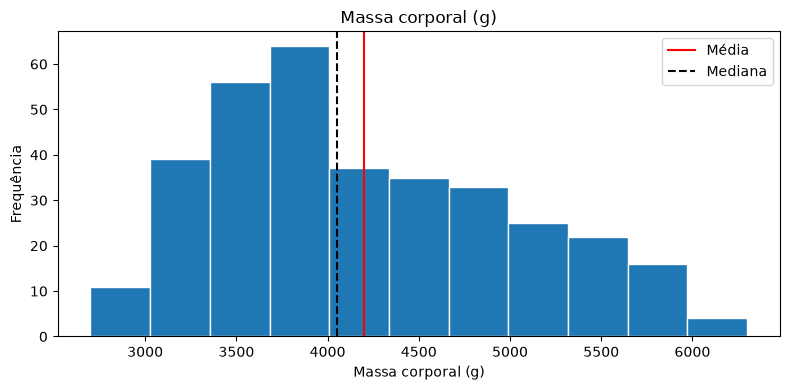

In [7]:
# Apresentar o histograma de massa corporal
plot_dist(valores, 'Massa corporal (g)', boxplot=False)


**Figura 2 — Massa corporal (g).** A cauda se prolonga à direita, e a média supera a mediana, em concordância com a assimetria positiva. Como a base reúne espécies diferentes, essa forma descreve o conjunto das observações. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.


In [8]:
# Comparar média e mediana
print('Média (g):', round(massa.mean(), 2))
print('Mediana (g):', massa.median())

Média (g): 4201.75
Mediana (g): 4050.0


A média é 4.201,75 g e a mediana é 4.050 g. A diferença é compatível com assimetria positiva, mas deve ser interpretada junto ao histograma: a base reúne espécies diferentes.

### 4.2 Coeficiente de assimetria

O coeficiente de assimetria indica o desequilíbrio entre os lados da distribuição: valores positivos sugerem cauda mais longa à direita. Valores negativos sugerem cauda mais longa à esquerda. Em distribuições simétricas, aproxima-se de zero (BARBETTA; REIS; BORNIA, 2010, p. 85).

O cálculo básico usa as médias dos desvios quadráticos e cúbicos:

$$
m_2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2,
\qquad
m_3=\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^3.
$$

Em que:

- $x_i$: cada valor observado;
- $\bar{x}$: média dos valores observados;
- $n$: quantidade de observações não ausentes;
- $m_2$: média dos desvios quadráticos em relação à média;
- $m_3$: média dos desvios cúbicos em relação à média.

O coeficiente básico e sua versão ajustada são:

$$
g_1=\frac{m_3}{m_2^{3/2}},
\qquad
G_1=\frac{\sqrt{n(n-1)}}{n-2}\,g_1.
$$

$g_1$ é o coeficiente básico. $G_1$ é o coeficiente ajustado retornado por `stats.skew(massa, bias=False)`, para $n>2$ e $m_2>0$. O cubo preserva o sinal dos desvios, enquanto o denominador retira a unidade de medida ([SciPy, documentação de skew](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html)).

Calcule com `stats.skew(massa, bias=False)`. O parâmetro `bias=False` aplica uma correção que depende do tamanho da amostra ([SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html)). Interprete o resultado junto ao histograma: um valor próximo de zero não garante simetria.

In [9]:
# Calcular a assimetria ajustada
assimetria = stats.skew(massa, bias=False)
print('Assimetria:', round(assimetria, 3))

Assimetria: 0.47


O coeficiente da massa é aproximadamente 0,470. O sinal positivo acompanha a leitura de maior prolongamento para valores altos; não permite concluir que a distribuição pertence a um modelo específico.

### 4.3 Curtose

Além da direção da assimetria, podemos observar a presença de valores muito afastados da média. A **curtose** é uma medida sensível à intensidade desses afastamentos, considerando a dispersão. Poucos valores muito extremos podem elevar seu resultado ([SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html)).

Para interpretá-la, usamos uma referência: a **distribuição normal**, um modelo simétrico em forma de sino. Na convenção de Pearson, sua curtose é **3**. Valores abaixo ou acima de 3 indicam menor ou maior peso dos afastamentos extremos em relação a esse modelo. Curtose próxima de 3 não garante distribuição normal.

O coeficiente básico de curtose de Pearson é:

$$
b_2=\frac{m_4}{m_2^2},\qquad
m_4=\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^4.
$$

Em que:

- $x_i$: cada valor observado.
- $\bar{x}$: média dos valores observados.
- $n$: quantidade de observações não ausentes.
- $m_2$: média dos desvios quadráticos, definida na seção 4.2.
- $m_4$: média dos desvios elevados à quarta potência.
- $b_2$: coeficiente básico de curtose de Pearson, definido quando $m_2>0$.

A quarta potência dá grande peso aos afastamentos maiores. A divisão por $m_2^2$ permite comparar distribuições com dispersões diferentes. No cálculo pela biblioteca, `bias=False` aplica um ajuste amostral ao coeficiente básico ([SciPy, documentação de kurtosis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html)).

A figura 3 compara três modelos com **média 0 e desvio padrão 1**: uniforme, com valores igualmente prováveis em intervalos de mesma largura dentro de seus limites, normal e Laplace, que neste exemplo tem pico mais pontudo. O eixo vertical mostra a **densidade**: a área sob a curva em um intervalo representa sua probabilidade. As curvas serão apenas interpretadas, sem aprofundar esses modelos.


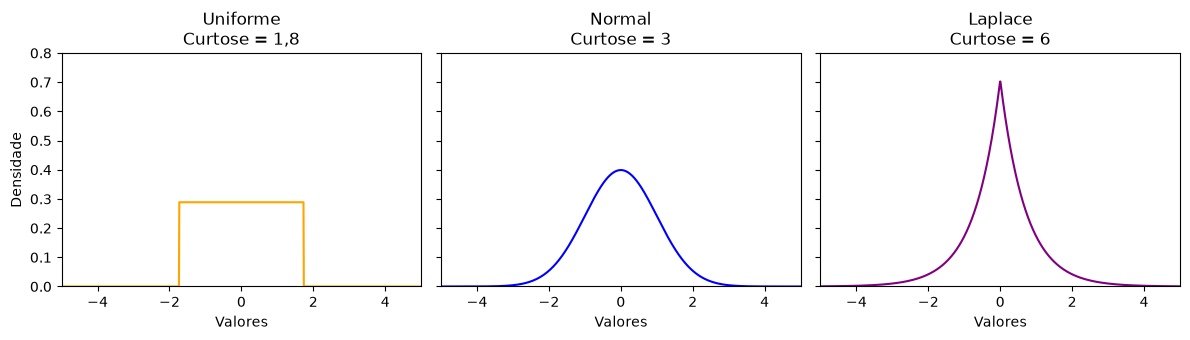

In [10]:
# Comparar distribuições com a mesma média e o mesmo desvio padrão
import numpy as np

x = np.linspace(-5, 5, 1000)
uniforme = stats.uniform.pdf(x, loc=-np.sqrt(3), scale=2 * np.sqrt(3))
normal = stats.norm.pdf(x)
laplace = stats.laplace.pdf(x, scale=1 / np.sqrt(2))

fig, eixos = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
eixos[0].plot(x, uniforme, color='orange')
eixos[0].set_title('Uniforme\nCurtose = 1,8')
eixos[1].plot(x, normal, color='blue')
eixos[1].set_title('Normal\nCurtose = 3')
eixos[2].plot(x, laplace, color='purple')
eixos[2].set_title('Laplace\nCurtose = 6')

for eixo in eixos:
    eixo.set_xlabel('Valores')
    eixo.set_xlim(-5, 5)
    eixo.set_ylim(0, 0.8)

eixos[0].set_ylabel('Densidade')
plt.tight_layout()
plt.show()


**Figura 3 — Distribuições com diferentes curtoses.** As curvas têm média 0 e desvio padrão 1. Em relação à normal (curtose 3), os afastamentos extremos têm menor peso na uniforme (1,8) e maior peso na Laplace (6). A curtose não determina, isoladamente, a altura do pico. Fonte: CARUBBI, 2026.


**Exemplo pronto:** observe a curtose da massa corporal. `fisher=False` seleciona a convenção de Pearson, com referência 3.


In [11]:
# Exemplo pronto: curtose de Pearson da massa corporal
curtose = stats.kurtosis(massa, fisher=False, bias=False)
print('Curtose:', round(curtose, 3))

Curtose: 2.281


A curtose de **2,281**, abaixo de 3, indica menor contribuição de valores afastados da média, em relação à dispersão, do que na distribuição normal. Isso não significa ausência de valores discrepantes.


### 4.4 Interpretação conjunta de gráficos e coeficientes

Retome o coeficiente de assimetria para interpretar as medidas da nadadeira e do bico:

- Compare o sinal do coeficiente com a direção da cauda mais longa.
- Observe as posições da média e da mediana.
- Identifique concentrações no histograma que não aparecem separadamente no boxplot.

O coeficiente resume o desequilíbrio entre os lados, mas não descreve toda a forma da distribuição.


In [12]:
# Preparar os valores observados
valores = df['FLIPPER_LENGTH'].dropna()

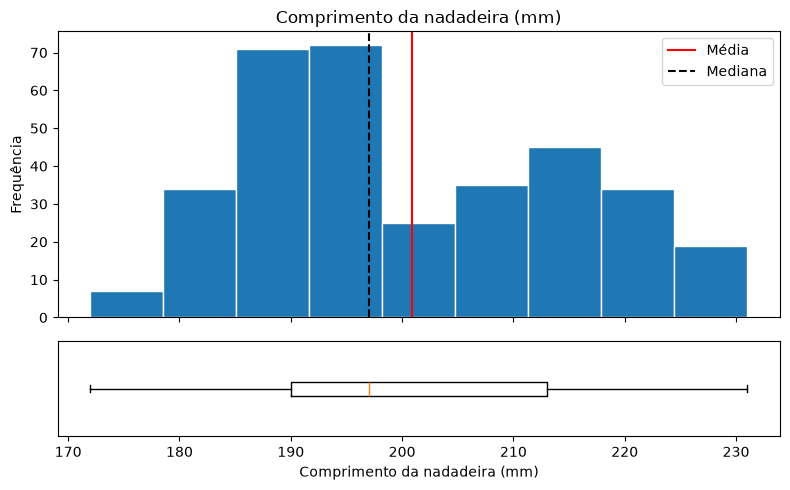

In [13]:
# Comparar histograma e boxplot na mesma escala
plot_dist(valores, 'Comprimento da nadadeira (mm)')


**Figura 4 — Comprimento da nadadeira (mm).** O histograma sugere duas concentrações de valores, que não aparecem separadamente no boxplot. A média acima da mediana acompanha a assimetria positiva. O boxplot resume a posição e a dispersão, mas não revela os picos. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.


In [14]:
# Calcular a assimetria de comprimento da nadadeira (mm)
print('Observações:', len(valores))
print('Assimetria:', round(stats.skew(valores, bias=False), 3))


Observações: 342
Assimetria: 0.346


In [15]:
# Preparar os valores observados
valores = df['CULMEN_LENGTH'].dropna()

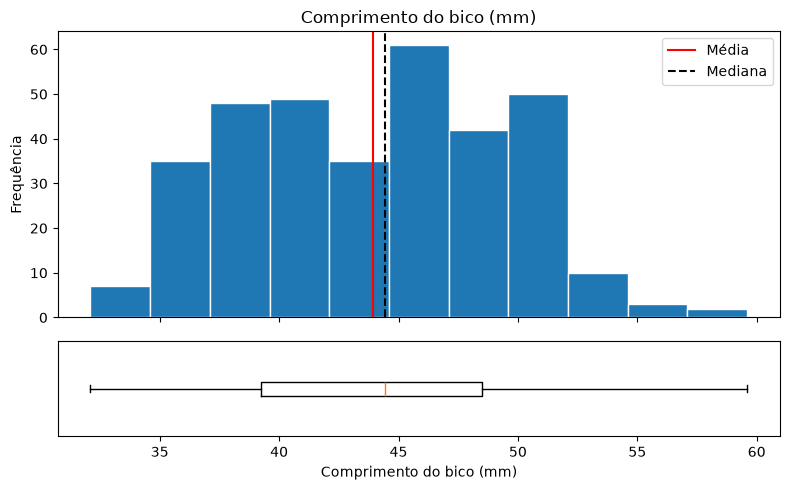

In [16]:
# Comparar histograma e boxplot na mesma escala
plot_dist(valores, 'Comprimento do bico (mm)')


**Figura 5 — Comprimento do bico (mm).** A média e a mediana estão próximas, mas o histograma apresenta concentrações distintas. Assimetria próxima de zero não garante simetria nem uma distribuição normal. Essas concentrações não são representadas no boxplot. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.


In [17]:
# Calcular a assimetria de comprimento do bico (mm)
print('Observações:', len(valores))
print('Assimetria:', round(stats.skew(valores, bias=False), 3))


Observações: 342
Assimetria: 0.053


In [18]:
# Preparar os valores observados
valores = df['CULMEN_DEPTH'].dropna()

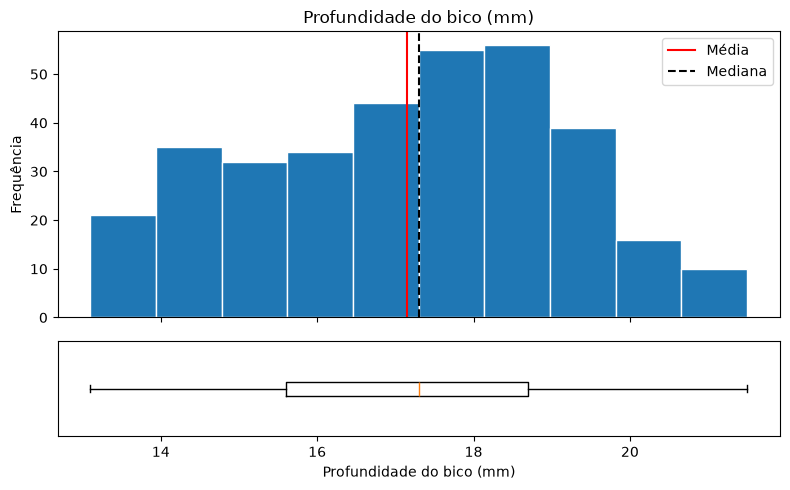

In [19]:
# Comparar histograma e boxplot na mesma escala
plot_dist(valores, 'Profundidade do bico (mm)')


**Figura 6 — Profundidade do bico (mm).** A média ligeiramente abaixo da mediana acompanha a pequena assimetria negativa. O histograma mostra maior concentração entre 17 e 19 mm e valores que se estendem para medidas menores. O coeficiente resume o desequilíbrio, mas não toda a forma da distribuição. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.


In [20]:
# Calcular a assimetria de profundidade do bico (mm)
print('Observações:', len(valores))
print('Assimetria:', round(stats.skew(valores, bias=False), 3))


Observações: 342
Assimetria: -0.143


A assimetria é aproximadamente 0,346 para nadadeira, 0,053 para comprimento do bico e −0,143 para profundidade do bico. O comprimento do bico exemplifica por que assimetria próxima de zero não basta para declarar normalidade.

## 5. Identificação de valores discrepantes

As **cercas de Tukey** são limites calculados a partir dos quartis:

$$
L=Q_1-1{,}5\operatorname{IQR},\qquad U=Q_3+1{,}5\operatorname{IQR}.
$$

Aqui, $L$ é a cerca inferior e $U$, a superior. Valores menores que $L$ ou maiores que $U$ são **valores discrepantes pelo critério de Tukey**. As hastes do boxplot terminam nas observações mais extremas que permanecem dentro das cercas. Elas não terminam necessariamente nas cercas calculadas (MORETTIN; BUSSAB, 2010, p. 48).

Compare as massas originais de Gentoo, Adelie e Chinstrap. As cercas de Tukey são calculadas separadamente para cada espécie.


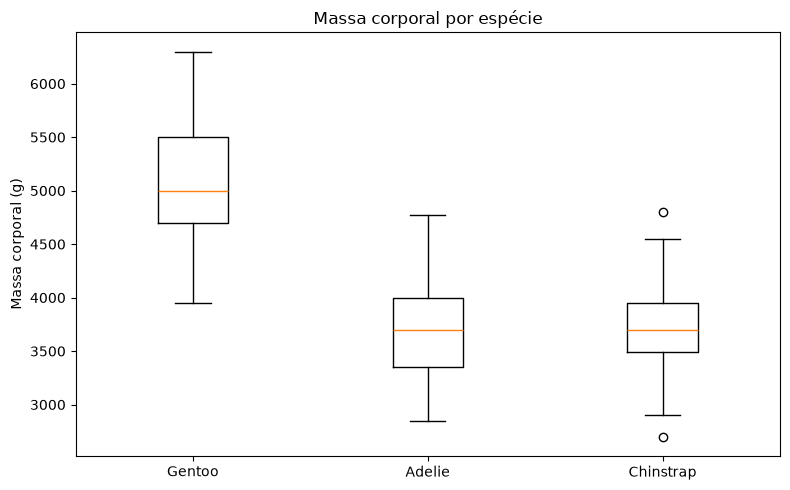

In [21]:
# Selecionar a massa corporal de cada espécie
gentoo = df.loc[df['SPECIES'] == 'Gentoo', 'BODY_MASS'].dropna()
adelie = df.loc[df['SPECIES'] == 'Adelie', 'BODY_MASS'].dropna()
chinstrap = df.loc[df['SPECIES'] == 'Chinstrap', 'BODY_MASS'].dropna()

# Colunas e rótulos para o boxplot
cols_especies = [gentoo, adelie, chinstrap]
rotulos = ['Gentoo', 'Adelie', 'Chinstrap']

# Comparar as espécies em um único painel
fig, eixo = plt.subplots(figsize=(8, 5))
eixo.boxplot(cols_especies, orientation='vertical', whis=1.5, tick_labels=rotulos)
eixo.set_ylabel('Massa corporal (g)')
eixo.set_title('Massa corporal por espécie')
plt.tight_layout()
plt.show()


**Figura 7 — Massa corporal por espécie.** Chinstrap apresenta dois discrepantes pelo critério de Tukey: 2.700 g e 4.800 g. Gentoo e Adelie não apresentam discrepantes. Esses valores de Chinstrap não são discrepantes pelas cercas da base completa, mostrando que a classificação depende do grupo analisado. Isso não comprova erro nos registros. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.


In [22]:
# Calcular os quartis e o intervalo interquartil da massa
q1 = massa.quantile(0.25)
q3 = massa.quantile(0.75)
iqr = q3 - q1
print('Q1, Q3 e IQR (g):', q1, q3, iqr)

Q1, Q3 e IQR (g): 3550.0 4750.0 1200.0


In [23]:
# Calcular as cercas da massa
inferior = q1 - 1.5 * iqr
superior = q3 + 1.5 * iqr
print('Cercas (g):', inferior, superior)

Cercas (g): 1750.0 6550.0


In [24]:
# Sinalizar massas fora das cercas
fora = (df['BODY_MASS'] < inferior) | (df['BODY_MASS'] > superior)
print('Massas sinalizadas:', fora.sum())


Massas sinalizadas: 0


In [25]:
# Verificar as cercas para as espécies da Figura 7
especies = ['Gentoo', 'Adelie', 'Chinstrap']
for especie in especies:
    valores = df.loc[df['SPECIES'] == especie, 'BODY_MASS'].dropna()
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)
    iqr = q3 - q1
    inferior = q1 - 1.5 * iqr
    superior = q3 + 1.5 * iqr
    fora = (valores < inferior) | (valores > superior)
    print(especie)
    print('Cercas (g):', round(inferior, 2), round(superior, 2))
    print('Quantidade de discrepantes:', fora.sum())
    print('Massas discrepantes (g):', valores[fora].tolist())
    print()


Gentoo
Cercas (g): 3500.0 6700.0
Quantidade de discrepantes: 0
Massas discrepantes (g): []

Adelie
Cercas (g): 2375.0 4975.0
Quantidade de discrepantes: 0
Massas discrepantes (g): []

Chinstrap
Cercas (g): 2793.75 4643.75
Quantidade de discrepantes: 2
Massas discrepantes (g): [4800.0, 2700.0]



Na análise conjunta das espécies, nenhuma massa ultrapassa as cercas de 1.750 g e 6.550 g. Na análise por espécie, Gentoo e Adelie não apresentam discrepantes. Em Chinstrap, as massas de 2.700 g e 4.800 g são discrepantes, confirmando os pontos da Figura 7. Portanto, a classificação depende do grupo analisado.


Um valor discrepante não é necessariamente um erro. Verifique a unidade e o contexto antes de decidir sobre seu tratamento. Preserve os dados originais e documente qualquer alteração.


## 6. Acompanhamento da AP1

Nos 30 minutos finais, revise o projeto do grupo com Ames Housing, conforme [AP1](../../trabalhos/ap1.md): repositório e acesso docente, arquivo bruto, importação, estrutura, nomes das colunas, tipos, ausências e decisões iniciais de preparação.

Apresente o que já foi realizado, as evidências das decisões e as pendências. O acompanhamento é formativo e não exige antecipar análises previstas para etapas posteriores.

## 7. Estudo e exercícios


### 7.1 Materiais didáticos

- BARBETTA; REIS; BORNIA (2010), capítulo 3, pp. 67–68 e 77–78: forma das distribuições e sensibilidade da média e da mediana a valores extremos.
- PINHEIRO et al. (2009), seções 1.7–1.9, pp. 41–46: robustez das medidas, identificação de discrepâncias e interpretação do boxplot.
- MORETTIN; BUSSAB (2010), seções 3.4–3.5, pp. 64–65 e 68: boxplot, limites e direção da assimetria.
- [Documentação do SciPy: skew](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html) e [kurtosis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html): convenções e ajustes dos coeficientes usados na aula.


### 7.2 Exercícios indicados

- PINHEIRO et al. (2009), exercício **1.4_P, itens b–d**, p. 55: mediana, intervalo interquartil, identificação de discrepâncias e explicação contextual de um valor elevado.

Justifique a interpretação sem assumir que todo valor discrepante é um erro.


## 8. Referências

1. BARBETTA, Pedro Alberto; REIS, Marcelo Menezes; BORNIA, Antonio Cezar. *Estatística para cursos de engenharia e informática*. 3. ed. São Paulo: Atlas, 2010.
2. PINHEIRO, João Ismael D. et al. *Estatística básica: a arte de trabalhar com dados*. Rio de Janeiro: Elsevier, 2009.
3. MORETTIN, Pedro A.; BUSSAB, Wilton O. *Estatística básica*. 6. ed. São Paulo: Saraiva, 2010.
4. SCIPY. *Documentação da versão 1.18.0*: [skew](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html) e [kurtosis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html).
5. HORST, Allison Marie; HILL, Alison Presmanes; GORMAN, Kristen B. *palmerpenguins: Palmer Archipelago (Antarctica) penguin data*. Versão 0.1.0. Zenodo, 2020. DOI: [10.5281/zenodo.3960218](https://doi.org/10.5281/zenodo.3960218).

6. ESCOVEDO, Tatiana; MARQUES, Thiago; KALINOWSKI, Marcos. **Introdução à Estatística para Ciência de Dados**. Casa do Código, 2025.
